In [1]:
import pandas as pd
import numpy as np

## CRZ Entries

In [8]:
df_crz_entries = pd.read_csv('MTA_Congestion_Relief_Zone_Vehicle_Entries__Beginning_2025_20251106.csv')
df_crz_entries.head()

,Toll Date,Toll Hour,Toll 10 Minute Block,Minute of Hour,Hour of Day,Day of Week Int,Day of Week,Toll Week,Time Period,Vehicle Class,Detection Group,Detection Region,CRZ Entries,Excluded Roadway Entries
0,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,2 - Single-Unit Trucks,West Side Highway at 60th St,West Side Highway,6,0
1,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Queensboro Bridge,Queens,2,0
2,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Queens Midtown Tunnel,Queens,0,0
3,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Lincoln Tunnel,New Jersey,1,0
4,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Holland Tunnel,New Jersey,0,0


In [9]:
df_crz_entries

,Toll Date,Toll Hour,Toll 10 Minute Block,Minute of Hour,Hour of Day,Day of Week Int,Day of Week,Toll Week,Time Period,Vehicle Class,Detection Group,Detection Region,CRZ Entries,Excluded Roadway Entries
0,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,2 - Single-Unit Trucks,West Side Highway at 60th St,West Side Highway,6,0
1,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Queensboro Bridge,Queens,2,0
2,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Queens Midtown Tunnel,Queens,0,0
3,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Lincoln Tunnel,New Jersey,1,0
4,08/29/2025,08/29/2025 09:00:00 AM,08/29/2025 09:50:00 AM,50,9,6,Friday,08/24/2025,Peak,5 - Motorcycles,Holland Tunnel,New Jersey,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45355,08/01/2025,08/01/2025 05:00:00 AM,08/01/2025 05:00:00 AM,0,5,6,Friday,07/27/2025,Peak,"1 - Cars, Pickups and Vans",Queensboro Bridge,Queens,52,0
45356,08/01/2025,08/01/2025 05:00:00 AM,08/01/2025 05:00:00 AM,0,5,6,Friday,07/27/2025,Peak,"1 - Cars, Pickups and Vans",Queens Midtown Tunnel,Queens,51,0
45357,08/01/2025,08/01/2025 05:00:00 AM,08/01/2025 05:00:00 AM,0,5,6,Friday,07/27/2025,Peak,"1 - Cars, Pickups and Vans",Lincoln Tunnel,New Jersey,124,0
45358,08/01/2025,08/01/2025 05:00:00 AM,08/01/2025 05:00:00 AM,0,5,6,Friday,07/27/2025,Peak,"1 - Cars, Pickups and Vans",Holland Tunnel,New Jersey,82,0


In [10]:
df_crz_entries.groupby(['Toll Date']).sum()['CRZ Entries']

,CRZ Entries
Toll Date,
08/01/2025,122282
08/04/2025,130991
08/05/2025,136976
08/06/2025,135820
08/07/2025,133094
08/08/2025,123202
08/11/2025,129865
08/12/2025,133253
08/13/2025,133478


In [11]:
df_crz_entries.groupby(['Toll Date']).sum()['CRZ Entries'].max()

136976

In [12]:
df_date_val = df_crz_entries[df_crz_entries['Toll Date'] == '08/05/2025']
df_date_val[df_date_val['Vehicle Class'] == 'TLC Taxi/FHV'].sum()

,0
Toll Date,08/05/202508/05/202508/05/202508/05/202508/05/...
Toll Hour,08/05/2025 09:00:00 AM08/05/2025 09:00:00 AM08...
Toll 10 Minute Block,08/05/2025 09:50:00 AM08/05/2025 09:50:00 AM08...
Minute of Hour,9000
Hour of Day,2520
Day of Week Int,1080
Day of Week,TuesdayTuesdayTuesdayTuesdayTuesdayTuesdayTues...
Toll Week,08/03/202508/03/202508/03/202508/03/202508/03/...
Time Period,PeakPeakPeakPeakPeakPeakPeakPeakPeakPeakPeakPe...
Vehicle Class,TLC Taxi/FHVTLC Taxi/FHVTLC Taxi/FHVTLC Taxi/F...


In [13]:
df_crz_entries['CRZ Entries'].sum()/len(df_crz_entries['Toll Date'].unique())

np.float64(128347.23809523809)

In [14]:
df_crz_entries['Excluded Roadway Entries'].sum()

np.int64(383489)

In [15]:
df_1 = df_crz_entries[df_crz_entries['Vehicle Class'] == '1 - Cars, Pickups and Vans']
df_2 = df_crz_entries[df_crz_entries['Vehicle Class'] == 'TLC Taxi/FHV']
(df_1['CRZ Entries'].sum() + df_2['CRZ Entries'].sum())/len(df_crz_entries['Toll Date'].unique())

np.float64(114973.47619047618)

In [16]:
df_crz_entries[df_crz_entries['Vehicle Class'] == 'TLC Taxi/FHV']['CRZ Entries'].sum()/len(df_crz_entries['Toll Date'].unique())

np.float64(34648.666666666664)

In [17]:
df_crz_entries[df_crz_entries['Vehicle Class'] == '1 - Cars, Pickups and Vans']['CRZ Entries'].sum()/len(df_crz_entries['Toll Date'].unique())

np.float64(80324.80952380953)

In [18]:
df_crz_entries['Vehicle Class'].unique()

array(['2 - Single-Unit Trucks', '5 - Motorcycles', '4 - Buses',
       '3 - Multi-Unit Trucks', '1 - Cars, Pickups and Vans',
       'TLC Taxi/FHV'], dtype=object)

In [19]:
34648.666666666664 / 114973.47619047618

0.30136226036398456

In [20]:
34648.666666666664 / 128347.23809523809

0.26996036051010425

In [21]:
80324.80952380953 / 128347.23809523809

0.6258397976916787

## TLC Data

/tmp/ipython-input-3488718931.py:64: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-3488718931.py:104: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"]=df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-3488718931.py:105: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"]=df["DO_in_cbd"].fillna(False).astype(bool)



=== Yellow Taxi – Weekdays Aug 2025 (5–10 AM) ===
Within CRZ:     avg daily trips = 5,857.71, mean within-CRZ dist = 5.785 mi
Outside→Inside: avg daily trips = 3,924.62, mean within-CRZ dist = 11.236 mi
All ending in CRZ: avg daily trips = 9,782.33, weighted mean within-CRZ dist = 7.972 mi


/tmp/ipython-input-3488718931.py:78: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c=z.geometry.centroid


Saved map to yellow_crz_map.png


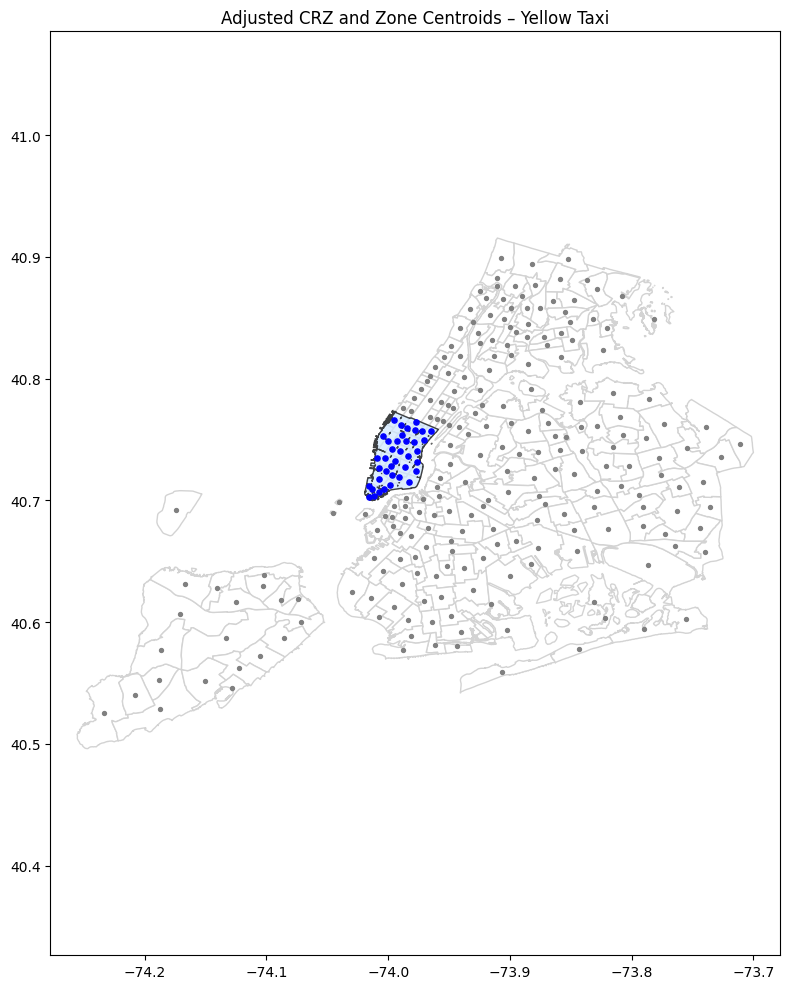

In [5]:
import io, zipfile, tempfile, requests, math
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import box, LineString
from shapely.ops import unary_union
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
YELLOW_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with tempfile.TemporaryDirectory() as td:
        td_path = Path(td)

        with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
            zf.extractall(td_path)

        # Find the shapefile explicitly (robust across geopandas backends)
        shp_files = list(td_path.rglob("*.shp"))
        if not shp_files:
            raise FileNotFoundError(
                f"No .shp found after extracting zones zip to {td_path}. "
                f"Extracted files: {[p.name for p in td_path.rglob('*') if p.is_file()]}"
            )

        # Prefer a file named like taxi_zones.shp if present
        shp = next((p for p in shp_files if p.name.lower() == "taxi_zones.shp"), shp_files[0])

        gdf = gpd.read_file(shp)

    # Normalize / clean
    gdf = gdf.to_crs(epsg=4326)
    gdf.columns = [c.lower() for c in gdf.columns]

    # Some versions store LocationID as object/float; coerce safely
    gdf["locationid"] = pd.to_numeric(gdf["locationid"], errors="raise").astype(int)

    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid", "borough", "zone", "geometry"]]


def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

def plot_map(zones,inside):
    z=zones.copy(); z["in_cbd"]=z["locationid"].map(inside)
    crz=unary_union(z.loc[z["in_cbd"],"geometry"])
    crz_g=gpd.GeoDataFrame(geometry=[crz],crs=4326)
    fig,ax=plt.subplots(figsize=(8,10))
    zones.plot(ax=ax,facecolor="white",edgecolor="lightgray")
    crz_g.plot(ax=ax,facecolor="#cfe8ff",edgecolor="black",alpha=0.7)
    c=z.geometry.centroid
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==False],crs=4326).plot(ax=ax,color="gray",markersize=8)
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==True],crs=4326).plot(ax=ax,color="blue",markersize=14)
    ax.set_aspect("equal","datalim"); ax.set_title("Adjusted CRZ and Zone Centroids – Yellow Taxi")
    plt.tight_layout(); plt.savefig("yellow_crz_map.png",dpi=200)
    print("Saved map to yellow_crz_map.png")

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load Yellow Taxi data
cols=["PULocationID","DOLocationID","trip_distance","tpep_pickup_datetime"]
df=pd.read_parquet(YELLOW_URL,columns=cols)
df=df.dropna(subset=["PULocationID","DOLocationID","tpep_pickup_datetime"])
df["PULocationID"]=df["PULocationID"].astype("int32")
df["DOLocationID"]=df["DOLocationID"].astype("int32")
df["pickup_dt"]=pd.to_datetime(df["tpep_pickup_datetime"],errors="coerce")
df=df.dropna(subset=["pickup_dt"])

# Merge CRZ flags
df=df.merge(inside.rename("PU_in_cbd"),left_on="PULocationID",right_index=True,how="left")
df=df.merge(inside.rename("DO_in_cbd"),left_on="DOLocationID",right_index=True,how="left")
df["PU_in_cbd"]=df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"]=df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: weekdays Aug 2025 5–10 AM
dt=df["pickup_dt"]
mask=(dt.dt.year==2025)&(dt.dt.month==8)&(dt.dt.weekday<5)&(dt.dt.hour>=START_HOUR)&(dt.dt.hour<END_HOUR)
df=df[mask].copy()

# --- 1. Within CRZ ---
within=df[(df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
within["day"]=within["pickup_dt"].dt.date
avg_within_ct=within.groupby("day").size().mean()
avg_within_dist=within["trip_distance"].mean()

# --- 2. Outside → Inside CRZ ---
centroids=zones.set_index("locationid").geometry.centroid
cbd_poly=cbd.geometry.iloc[0]
def frac_inside(pu,do):
    pu_pt,do_pt=centroids.get(pu),centroids.get(do)
    if pu_pt is None or do_pt is None: return 0.0
    line=LineString([pu_pt,do_pt])
    inter=line.intersection(cbd_poly)
    if inter.is_empty: return 0.0
    return inter.length/line.length if line.length>0 else 0.0

out_in=df[(~df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
out_in["frac_inside"]=out_in.apply(lambda r:frac_inside(r["PULocationID"],r["DOLocationID"]),axis=1)
out_in["inside_miles"]=out_in["trip_distance"]*out_in["frac_inside"]
out_in["day"]=out_in["pickup_dt"].dt.date
avg_inflow_ct=out_in.groupby("day").size().mean()
avg_inflow_dist=out_in["inside_miles"].mean()

# --- 3. All ending in CRZ (weighted within-CRZ distance) ---
ends_ct=avg_within_ct+avg_inflow_ct
if ends_ct>0:
    ends_avg_within_dist=((avg_within_dist*avg_within_ct)+(avg_inflow_dist*avg_inflow_ct))/ends_ct
else:
    ends_avg_within_dist=float("nan")

# --- Results ---
print("\n=== Yellow Taxi – Weekdays Aug 2025 (5–10 AM) ===")
print(f"Within CRZ:     avg daily trips = {avg_within_ct:,.2f}, mean within-CRZ dist = {avg_within_dist:.3f} mi")
print(f"Outside→Inside: avg daily trips = {avg_inflow_ct:,.2f}, mean within-CRZ dist = {avg_inflow_dist:.3f} mi")
print(f"All ending in CRZ: avg daily trips = {ends_ct:,.2f}, weighted mean within-CRZ dist = {ends_avg_within_dist:.3f} mi")

plot_map(zones,inside)


/tmp/ipython-input-3073152119.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-3073152119.py:99: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"]=df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-3073152119.py:100: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"]=df["DO_in_cbd"].fillna(False).astype(bool)
/


=== Green Taxi – Weekdays Aug 2025 (5–10 AM) ===
Within CRZ:   avg daily trips = 1.00, mean within-CRZ dist = 3.144 mi
Outside→Inside: avg daily trips = 30.81, mean within-CRZ dist = 1.698 mi
All ending in CRZ: avg daily trips = 31.81, weighted mean within-CRZ dist = 1.744 mi


/tmp/ipython-input-3073152119.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c=z.geometry.centroid


Saved map to green_crz_map.png


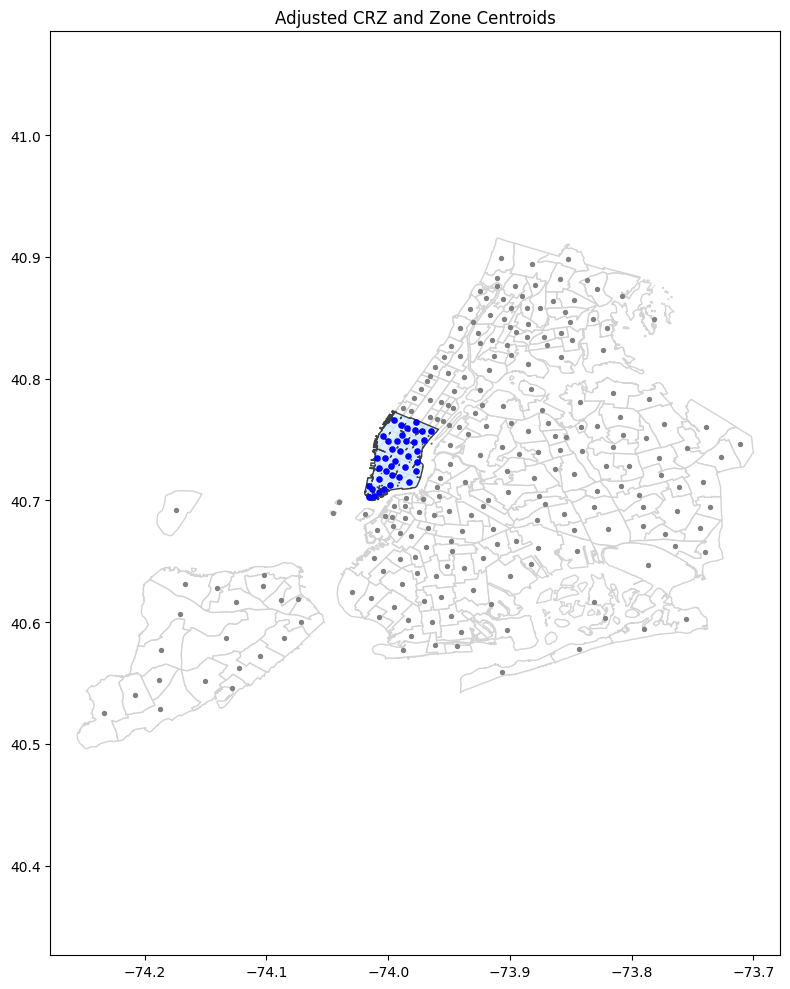

In [7]:
import io, zipfile, tempfile, requests, math
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import box, LineString
from shapely.ops import unary_union
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
GREEN_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with tempfile.TemporaryDirectory() as td:
        td_path = Path(td)

        with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
            zf.extractall(td_path)

        shp_files = list(td_path.rglob("*.shp"))
        if not shp_files:
            raise FileNotFoundError(
                f"No .shp found after extracting zones zip to {td_path}. "
                f"Files: {[p.name for p in td_path.rglob('*') if p.is_file()]}"
            )

        # Prefer taxi_zones.shp if present
        shp = next((p for p in shp_files if p.name.lower() == "taxi_zones.shp"), shp_files[0])

        gdf = gpd.read_file(shp)

    gdf = gdf.to_crs(epsg=4326)
    gdf.columns = [c.lower() for c in gdf.columns]
    gdf["locationid"] = pd.to_numeric(gdf["locationid"], errors="raise").astype(int)
    gdf = gdf.drop_duplicates("locationid")

    return gdf[["locationid", "borough", "zone", "geometry"]]

def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

def plot_map(zones,inside):
    z=zones.copy(); z["in_cbd"]=z["locationid"].map(inside)
    crz=unary_union(z.loc[z["in_cbd"],"geometry"])
    crz_g=gpd.GeoDataFrame(geometry=[crz],crs=4326)
    fig,ax=plt.subplots(figsize=(8,10))
    zones.plot(ax=ax,facecolor="white",edgecolor="lightgray")
    crz_g.plot(ax=ax,facecolor="#cfe8ff",edgecolor="black",alpha=0.7)
    c=z.geometry.centroid
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==False],crs=4326).plot(ax=ax,color="gray",markersize=8)
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==True],crs=4326).plot(ax=ax,color="blue",markersize=14)
    ax.set_aspect("equal","datalim"); ax.set_title("Adjusted CRZ and Zone Centroids")
    plt.tight_layout(); plt.savefig("green_crz_map.png",dpi=200)
    print("Saved map to green_crz_map.png")

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load Green Taxi data
cols=["PULocationID","DOLocationID","trip_distance","lpep_pickup_datetime"]
df=pd.read_parquet(GREEN_URL,columns=cols)
df=df.dropna(subset=["PULocationID","DOLocationID","lpep_pickup_datetime"])
df["PULocationID"]=df["PULocationID"].astype("int32")
df["DOLocationID"]=df["DOLocationID"].astype("int32")
df["pickup_dt"]=pd.to_datetime(df["lpep_pickup_datetime"],errors="coerce")
df=df.dropna(subset=["pickup_dt"])

# Merge flags
df=df.merge(inside.rename("PU_in_cbd"),left_on="PULocationID",right_index=True,how="left")
df=df.merge(inside.rename("DO_in_cbd"),left_on="DOLocationID",right_index=True,how="left")
df["PU_in_cbd"]=df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"]=df["DO_in_cbd"].fillna(False).astype(bool)

# Filter to weekdays Aug 2025 5–10 AM
dt=df["pickup_dt"]
mask=(dt.dt.year==2025)&(dt.dt.month==8)&(dt.dt.weekday<5)&(dt.dt.hour>=START_HOUR)&(dt.dt.hour<END_HOUR)
df=df[mask].copy()

# --- 1. Within CRZ ---
within=df[(df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
within["day"]=within["pickup_dt"].dt.date
avg_within_ct=within.groupby("day").size().mean()
avg_within_dist=within["trip_distance"].mean()

# --- 2. Outside → Inside CRZ ---
centroids=zones.set_index("locationid").geometry.centroid
cbd_poly=cbd.geometry.iloc[0]
def frac_inside(pu,do):
    pu_pt,do_pt=centroids.get(pu),centroids.get(do)
    if pu_pt is None or do_pt is None: return 0.0
    line=LineString([pu_pt,do_pt])
    inter=line.intersection(cbd_poly)
    if inter.is_empty: return 0.0
    return inter.length/line.length if line.length>0 else 0.0

out_in=df[(~df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
out_in["frac_inside"]=out_in.apply(lambda r:frac_inside(r["PULocationID"],r["DOLocationID"]),axis=1)
out_in["inside_miles"]=out_in["trip_distance"]*out_in["frac_inside"]
out_in["day"]=out_in["pickup_dt"].dt.date
avg_inflow_ct=out_in.groupby("day").size().mean()
avg_inflow_dist=out_in["inside_miles"].mean()

# --- 3. All ending in CRZ (using weighted within-CRZ distance) ---
ends_ct = avg_within_ct + avg_inflow_ct
if ends_ct>0:
    ends_avg_within_dist=((avg_within_dist*avg_within_ct)+(avg_inflow_dist*avg_inflow_ct))/ends_ct
else:
    ends_avg_within_dist=float("nan")

# --- Results ---
print("\n=== Green Taxi – Weekdays Aug 2025 (5–10 AM) ===")
print(f"Within CRZ:   avg daily trips = {avg_within_ct:,.2f}, mean within-CRZ dist = {avg_within_dist:.3f} mi")
print(f"Outside→Inside: avg daily trips = {avg_inflow_ct:,.2f}, mean within-CRZ dist = {avg_inflow_dist:.3f} mi")
print(f"All ending in CRZ: avg daily trips = {ends_ct:,.2f}, weighted mean within-CRZ dist = {ends_avg_within_dist:.3f} mi")

plot_map(zones,inside)


/tmp/ipython-input-4190927903.py:57: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-4190927903.py:97: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-4190927903.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool


=== FHV Trips – Weekdays Aug 2025 (5–10 AM) ===
Within CRZ: avg daily trips = 43.71
Outside → Inside: avg daily trips = 524.19
All ending in CRZ: avg daily trips = 567.90


/tmp/ipython-input-4190927903.py:71: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c=z.geometry.centroid


Saved map to fhv_crz_map.png


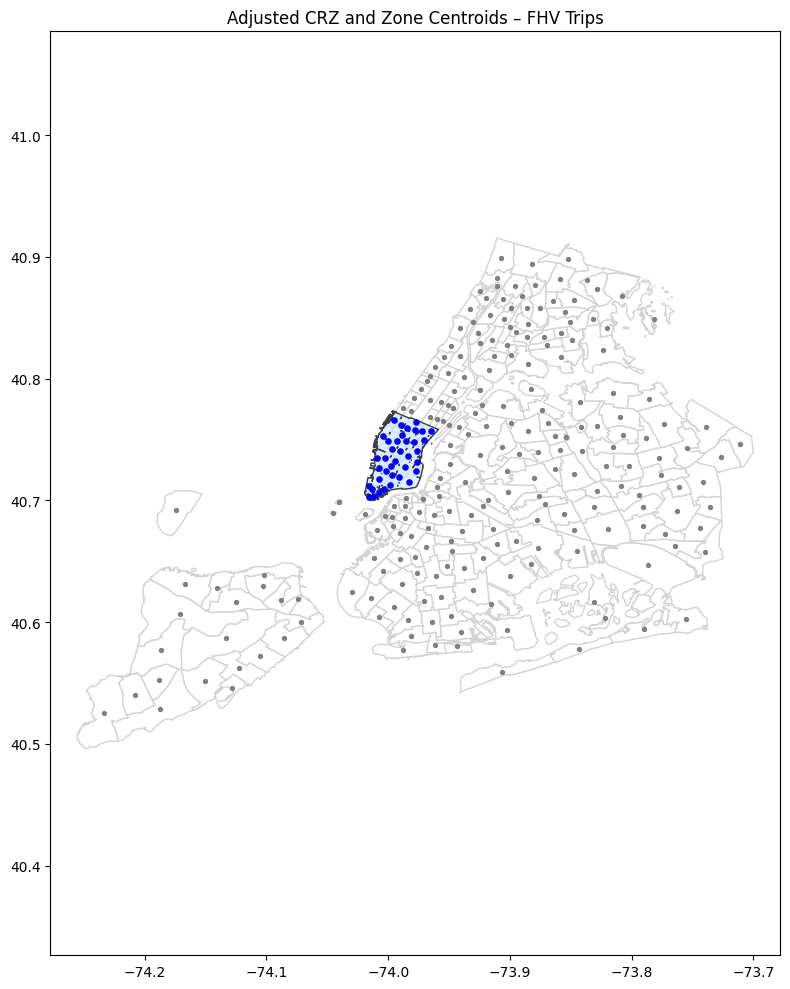

In [8]:
import io, zipfile, tempfile, requests
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import box
from shapely.ops import unary_union
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
FHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhv_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with tempfile.TemporaryDirectory() as td:
        td_path = Path(td)

        with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
            zf.extractall(td_path)

        shp_files = list(td_path.rglob("*.shp"))
        if not shp_files:
            raise FileNotFoundError(
                f"No .shp found after extracting zones zip to {td_path}. "
                f"Files: {[p.name for p in td_path.rglob('*') if p.is_file()]}"
            )

        shp = next((p for p in shp_files if p.name.lower() == "taxi_zones.shp"), shp_files[0])
        gdf = gpd.read_file(shp)

    gdf = gdf.to_crs(epsg=4326)
    gdf.columns = [c.lower() for c in gdf.columns]
    gdf["locationid"] = pd.to_numeric(gdf["locationid"], errors="raise").astype(int)
    gdf = gdf.drop_duplicates("locationid")

    return gdf[["locationid", "borough", "zone", "geometry"]]

def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

def plot_map(zones,inside):
    z=zones.copy(); z["in_cbd"]=z["locationid"].map(inside)
    crz=unary_union(z.loc[z["in_cbd"],"geometry"])
    crz_g=gpd.GeoDataFrame(geometry=[crz],crs=4326)
    fig,ax=plt.subplots(figsize=(8,10))
    zones.plot(ax=ax,facecolor="white",edgecolor="lightgray")
    crz_g.plot(ax=ax,facecolor="#cfe8ff",edgecolor="black",alpha=0.7)
    c=z.geometry.centroid
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==False],crs=4326).plot(ax=ax,color="gray",markersize=8)
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==True],crs=4326).plot(ax=ax,color="blue",markersize=14)
    ax.set_aspect("equal","datalim"); ax.set_title("Adjusted CRZ and Zone Centroids – FHV Trips")
    plt.tight_layout(); plt.savefig("fhv_crz_map.png",dpi=200)
    print("Saved map to fhv_crz_map.png")

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load FHV data
cols = ["PUlocationID","DOlocationID","pickup_datetime"]
df = pd.read_parquet(FHV_URL, columns=cols)
df = df.dropna(subset=["PUlocationID","DOlocationID","pickup_datetime"])
df["PULocationID"] = df["PUlocationID"].astype("int32")
df["DOLocationID"] = df["DOlocationID"].astype("int32")
df["pickup_dt"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter to weekdays Aug 2025 5–10 AM
dt = df["pickup_dt"]
mask = (dt.dt.year==2025)&(dt.dt.month==8)&(dt.dt.weekday<5)&(dt.dt.hour>=START_HOUR)&(dt.dt.hour<END_HOUR)
df = df[mask].copy()

# --- 1. Within CRZ ---
within = df[(df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
within["day"] = within["pickup_dt"].dt.date
avg_within_ct = within.groupby("day").size().mean()

# --- 2. Outside → Inside CRZ ---
out_in = df[(~df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
out_in["day"] = out_in["pickup_dt"].dt.date
avg_inflow_ct = out_in.groupby("day").size().mean()

# --- 3. All ending in CRZ ---
ends_ct = avg_within_ct + avg_inflow_ct

# --- Results ---
print("\n=== FHV Trips – Weekdays Aug 2025 (5–10 AM) ===")
print(f"Within CRZ: avg daily trips = {avg_within_ct:,.2f}")
print(f"Outside → Inside: avg daily trips = {avg_inflow_ct:,.2f}")
print(f"All ending in CRZ: avg daily trips = {ends_ct:,.2f}")

plot_map(zones,inside)


/tmp/ipython-input-156686393.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-156686393.py:99: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-156686393.py:100: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)



=== High-Volume FHV – Weekdays Aug 2025 (5–10 AM) ===
Within CRZ:  avg daily trips = 13,615.71, mean within-CRZ dist = 2.142 mi
Outside → Inside: avg daily trips = 12,855.67, mean within-CRZ dist = 2.104 mi
All ending in CRZ: avg daily trips = 26,471.38, weighted mean within-CRZ dist = 2.124 mi


/tmp/ipython-input-156686393.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c=z.geometry.centroid


Saved map to fhvhv_crz_map.png


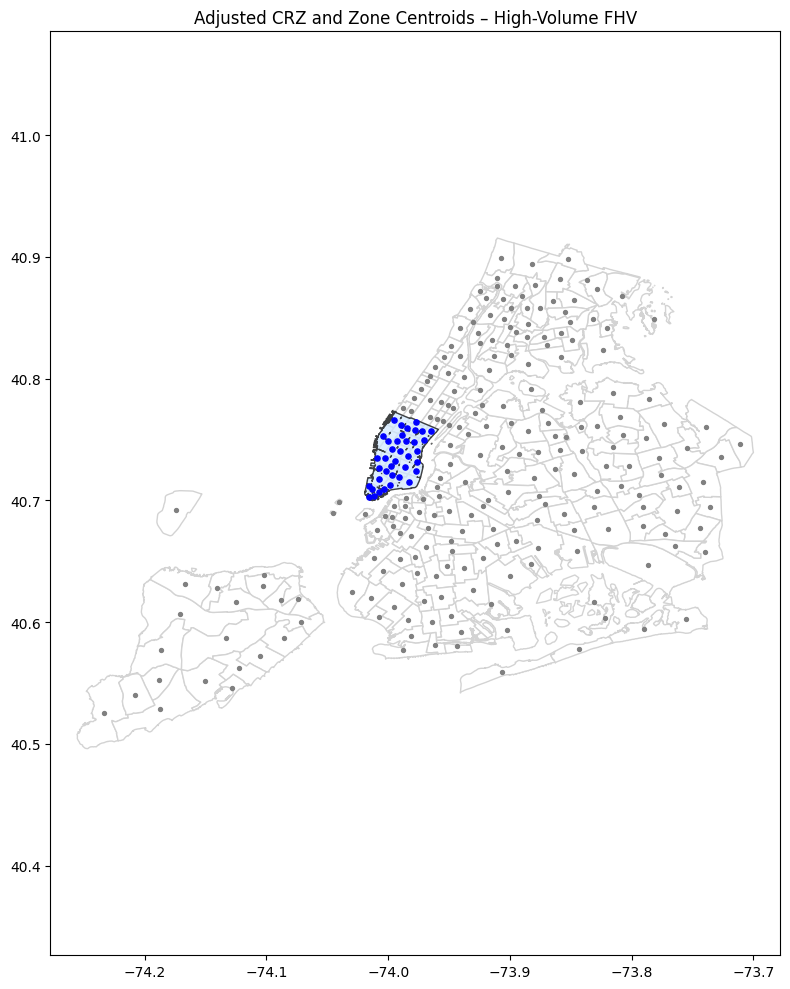

In [9]:
import io, zipfile, tempfile, requests, math
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import box, LineString
from shapely.ops import unary_union
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
HVFHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with tempfile.TemporaryDirectory() as td:
        td_path = Path(td)

        with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
            zf.extractall(td_path)

        shp_files = list(td_path.rglob("*.shp"))
        if not shp_files:
            raise FileNotFoundError(
                f"No .shp found after extracting zones zip to {td_path}. "
                f"Files: {[p.name for p in td_path.rglob('*') if p.is_file()]}"
            )

        shp = next((p for p in shp_files if p.name.lower() == "taxi_zones.shp"), shp_files[0])
        gdf = gpd.read_file(shp)

    gdf = gdf.to_crs(epsg=4326)
    gdf.columns = [c.lower() for c in gdf.columns]
    gdf["locationid"] = pd.to_numeric(gdf["locationid"], errors="raise").astype(int)
    gdf = gdf.drop_duplicates("locationid")

    return gdf[["locationid", "borough", "zone", "geometry"]]


def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

def plot_map(zones,inside):
    z=zones.copy(); z["in_cbd"]=z["locationid"].map(inside)
    crz=unary_union(z.loc[z["in_cbd"],"geometry"])
    crz_g=gpd.GeoDataFrame(geometry=[crz],crs=4326)
    fig,ax=plt.subplots(figsize=(8,10))
    zones.plot(ax=ax,facecolor="white",edgecolor="lightgray")
    crz_g.plot(ax=ax,facecolor="#cfe8ff",edgecolor="black",alpha=0.7)
    c=z.geometry.centroid
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==False],crs=4326).plot(ax=ax,color="gray",markersize=8)
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==True],crs=4326).plot(ax=ax,color="blue",markersize=14)
    ax.set_aspect("equal","datalim")
    ax.set_title("Adjusted CRZ and Zone Centroids – High-Volume FHV")
    plt.tight_layout(); plt.savefig("fhvhv_crz_map.png",dpi=200)
    print("Saved map to fhvhv_crz_map.png")

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load HVFHV data (has trip_miles)
cols = ["PULocationID","DOLocationID","trip_miles","pickup_datetime"]
df = pd.read_parquet(HVFHV_URL, columns=cols)
df = df.dropna(subset=["PULocationID","DOLocationID","pickup_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["pickup_dt"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter to weekdays Aug 2025 5–10 AM
dt = df["pickup_dt"]
mask = (dt.dt.year==2025)&(dt.dt.month==8)&(dt.dt.weekday<5)&(dt.dt.hour>=START_HOUR)&(dt.dt.hour<END_HOUR)
df = df[mask].copy()

# --- 1. Within CRZ ---
within = df[(df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
within["day"] = within["pickup_dt"].dt.date
avg_within_ct = within.groupby("day").size().mean()
avg_within_dist = within["trip_miles"].mean()

# --- 2. Outside → Inside CRZ ---
centroids = zones.set_index("locationid").geometry.centroid
cbd_poly = cbd.geometry.iloc[0]
def frac_inside(pu,do):
    pu_pt,do_pt = centroids.get(pu),centroids.get(do)
    if pu_pt is None or do_pt is None: return 0.0
    line = LineString([pu_pt,do_pt])
    inter = line.intersection(cbd_poly)
    if inter.is_empty: return 0.0
    return inter.length/line.length if line.length>0 else 0.0

out_in = df[(~df["PU_in_cbd"])&(df["DO_in_cbd"])].copy()
out_in["frac_inside"] = out_in.apply(lambda r: frac_inside(r["PULocationID"],r["DOLocationID"]), axis=1)
out_in["inside_miles"] = out_in["trip_miles"] * out_in["frac_inside"]
out_in["day"] = out_in["pickup_dt"].dt.date
avg_inflow_ct = out_in.groupby("day").size().mean()
avg_inflow_dist = out_in["inside_miles"].mean()

# --- 3. All ending in CRZ (weighted within-zone distance) ---
ends_ct = avg_within_ct + avg_inflow_ct
if ends_ct > 0:
    ends_avg_within_dist = ((avg_within_dist*avg_within_ct) + (avg_inflow_dist*avg_inflow_ct)) / ends_ct
else:
    ends_avg_within_dist = float("nan")

# --- Results ---
print("\n=== High-Volume FHV – Weekdays Aug 2025 (5–10 AM) ===")
print(f"Within CRZ:  avg daily trips = {avg_within_ct:,.2f}, mean within-CRZ dist = {avg_within_dist:.3f} mi")
print(f"Outside → Inside: avg daily trips = {avg_inflow_ct:,.2f}, mean within-CRZ dist = {avg_inflow_dist:.3f} mi")
print(f"All ending in CRZ: avg daily trips = {ends_ct:,.2f}, weighted mean within-CRZ dist = {ends_avg_within_dist:.3f} mi")

plot_map(zones,inside)



In [ ]:
import pandas as pd

HVFHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2025-08.parquet"

# Load necessary columns
cols = ["PULocationID", "DOLocationID", "pickup_datetime", "cbd_congestion_fee"]
df = pd.read_parquet(HVFHV_URL, columns=cols)

# Clean & filter
df = df.dropna(subset=["PULocationID","DOLocationID","pickup_datetime","cbd_congestion_fee"])
df["pickup_dt"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])

# Filter to Aug 2025 weekdays 5-10 AM
mask = (
    (df["pickup_dt"].dt.year == 2025) &
    (df["pickup_dt"].dt.month == 8) &
    (df["pickup_dt"].dt.weekday < 5) &
    (df["pickup_dt"].dt.hour >= 5) &
    (df["pickup_dt"].dt.hour < 10)
)
df_window = df[mask]

# Count trips that paid the congestion fee
count_paid = (df_window["cbd_congestion_fee"] > 0).sum()

print(f"Number of HVFHV trips paying the congestion fee in weekdays 5-10AM Aug 2025: {count_paid:,}")


Number of HVFHV trips paying the congestion fee in weekdays 5-10AM Aug 2025: 784,380


In [ ]:
784380/21

KeyError: 'PU_in_cbd'

In [ ]:
import io, zipfile, tempfile, requests, math
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import box, LineString
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
HVFHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

# ----------------------------
# MAIN
# ----------------------------
print("Loading zones & CRZ definition…")
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

print("Loading High-Volume FHV data…")
cols = ["PULocationID","DOLocationID","pickup_datetime","trip_miles","cbd_congestion_fee"]
df = pd.read_parquet(HVFHV_URL, columns=cols)
df = df.dropna(subset=["PULocationID","DOLocationID","pickup_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["pickup_dt"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])
df["cbd_congestion_fee"] = df["cbd_congestion_fee"].fillna(0)

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: Weekdays Aug 2025 5–10 AM
dt = df["pickup_dt"]
mask = (
    (dt.dt.year==2025) & (dt.dt.month==8) &
    (dt.dt.weekday<5) & (dt.dt.hour>=START_HOUR) & (dt.dt.hour<END_HOUR)
)
df = df[mask].copy()

# Identify trips that pay congestion fee
df["pays_fee"] = df["cbd_congestion_fee"] > 0

# Count total weekdays represented
num_days = df["pickup_dt"].dt.date.nunique()

# ----------------------------
# FEE-PAYING TRIP COUNTS BY FLOW TYPE
# ----------------------------
inside_inside_paid  = len(df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
outside_outside_paid= len(df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])
outside_inside_paid = len(df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
inside_outside_paid = len(df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])

# Optional: Daily averages
def daily_avg(total):
    return total / num_days if num_days else float("nan")

print("\n=== HVFHV Congestion-Fee Flow Matrix (Weekdays Aug 2025, 5–10 AM) ===")
print(f"Inside → Inside   : {inside_inside_paid:>10,}  (≈ {daily_avg(inside_inside_paid):,.1f}/day)")
print(f"Outside → Inside  : {outside_inside_paid:>10,}  (≈ {daily_avg(outside_inside_paid):,.1f}/day)")
print(f"Inside → Outside  : {inside_outside_paid:>10,}  (≈ {daily_avg(inside_outside_paid):,.1f}/day)")
print(f"Outside → Outside : {outside_outside_paid:>10,}  (≈ {daily_avg(outside_outside_paid):,.1f}/day)")

# Optional: overall share
total_paid = inside_inside_paid + outside_inside_paid + inside_outside_paid + outside_outside_paid
print(f"\nTotal fee-paying trips (all types): {total_paid:,}")


Loading zones & CRZ definition…


/tmp/ipython-input-3307036956.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid


Loading High-Volume FHV data…


/tmp/ipython-input-3307036956.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-3307036956.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)



=== HVFHV Congestion-Fee Flow Matrix (Weekdays Aug 2025, 5–10 AM) ===
Inside → Inside   :    283,752  (≈ 13,512.0/day)
Outside → Inside  :    263,426  (≈ 12,544.1/day)
Inside → Outside  :    185,504  (≈ 8,833.5/day)
Outside → Outside :     51,698  (≈ 2,461.8/day)

Total fee-paying trips (all types): 784,380


In [ ]:
import io, zipfile, tempfile, requests, math
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import box, LineString
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
HVFHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

CBD_ZONE_IDS = {
    4, 13, 45, 48, 50, 68, 79, 87, 90, 100, 107, 113, 114, 125, 137, 144, 148,
    158, 161, 162, 163, 164, 170, 186, 209, 211, 224, 229, 230, 231, 232, 233,
    234, 246, 249, 261
}

def _validate_cbd_ids(zones_gdf, ids):
    # Helpful sanity check — prints any IDs that don’t exist in the zones layer
    existing = set(zones_gdf["locationid"].astype(int))
    missing = sorted(set(ids) - existing)
    if missing:
        print(f"[warn] {len(missing)} CBD zone id(s) not found in taxi_zones: {missing}")

def build_cbd(zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Build the CRZ polygon by UNION of the listed TLC zones (explicit whitelist).
    """
    _validate_cbd_ids(zones, CBD_ZONE_IDS)
    sub = zones[zones["locationid"].isin(CBD_ZONE_IDS)]
    if sub.empty:
        raise ValueError("No zones matched CBD_ZONE_IDS; please check the list.")
    crz_geom = unary_union(sub.geometry.values).buffer(0)  # buffer(0) to clean topology
    return gpd.GeoDataFrame({"name": ["CRZ_manual_ids"]}, geometry=[crz_geom], crs="EPSG:4326")

def in_cbd_series(zones: gpd.GeoDataFrame, cbd_gdf: gpd.GeoDataFrame) -> pd.Series:
    """
    Mark a zone as in the CRZ **by ID membership**, not by centroid.
    This exactly reflects the manual list.
    """
    s = zones.set_index("locationid").index.to_series().isin(CBD_ZONE_IDS)
    s.index.name = "locationid"
    return s.astype(bool)

# ----------------------------
# MAIN
# ----------------------------
print("Loading zones & CRZ definition…")
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

print("Loading High-Volume FHV data…")
cols = ["PULocationID","DOLocationID","pickup_datetime","trip_miles","cbd_congestion_fee"]
df = pd.read_parquet(HVFHV_URL, columns=cols)
df = df.dropna(subset=["PULocationID","DOLocationID","pickup_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["pickup_dt"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])
df["cbd_congestion_fee"] = df["cbd_congestion_fee"].fillna(0)

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: Weekdays Aug 2025 5–10 AM
dt = df["pickup_dt"]
mask = (
    (dt.dt.year==2025) & (dt.dt.month==8) &
    (dt.dt.weekday<5) & (dt.dt.hour>=START_HOUR) & (dt.dt.hour<END_HOUR)
)
df = df[mask].copy()

# Identify trips that pay congestion fee
df["pays_fee"] = df["cbd_congestion_fee"] > 0

# Count total weekdays represented
num_days = df["pickup_dt"].dt.date.nunique()

# ----------------------------
# FEE-PAYING TRIP COUNTS BY FLOW TYPE
# ----------------------------
inside_inside_paid  = len(df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
outside_outside_paid= len(df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])
outside_inside_paid = len(df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
inside_outside_paid = len(df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])

# Optional: Daily averages
def daily_avg(total):
    return total / num_days if num_days else float("nan")

print("\n=== HVFHV Congestion-Fee Flow Matrix (Weekdays Aug 2025, 5–10 AM) ===")
print(f"Inside → Inside   : {inside_inside_paid:>10,}  (≈ {daily_avg(inside_inside_paid):,.1f}/day)")
print(f"Outside → Inside  : {outside_inside_paid:>10,}  (≈ {daily_avg(outside_inside_paid):,.1f}/day)")
print(f"Inside → Outside  : {inside_outside_paid:>10,}  (≈ {daily_avg(inside_outside_paid):,.1f}/day)")
print(f"Outside → Outside : {outside_outside_paid:>10,}  (≈ {daily_avg(outside_outside_paid):,.1f}/day)")

# Optional: overall share
total_paid = inside_inside_paid + outside_inside_paid + inside_outside_paid + outside_outside_paid
print(f"\nTotal fee-paying trips (all types): {total_paid:,}")


Loading zones & CRZ definition…
Loading High-Volume FHV data…


/tmp/ipython-input-3361548682.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-3361548682.py:86: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)



=== HVFHV Congestion-Fee Flow Matrix (Weekdays Aug 2025, 5–10 AM) ===
Inside → Inside   :    276,432  (≈ 13,163.4/day)
Outside → Inside  :    260,527  (≈ 12,406.0/day)
Inside → Outside  :    189,435  (≈ 9,020.7/day)
Outside → Outside :     57,986  (≈ 2,761.2/day)

Total fee-paying trips (all types): 784,380


In [ ]:
mask = df['PU_in_cbd'] | df['DO_in_cbd']
df_cbd_1 = df[mask]

# 2. Group by day and count trips
df_cbd_1['pickup_dt'] = df_cbd_1['pickup_datetime'].dt.date
daily_flow_1 = df_cbd_1.groupby('pickup_dt').size()

# 3. Maximum total flow across all days
max_flow = daily_flow_1.max()

# (optional) The day(s) with that maximum flow
max_days = daily_flow_1[daily_flow_1 == max_flow]

print("Maximum total CBD-related flow on a single day:", max_flow)
print("Day(s) achieving this:")
print(max_days)

Maximum total CBD-related flow on a single day: 40111
Day(s) achieving this:
pickup_dt
2025-08-06    40111
dtype: int64


/tmp/ipython-input-1759152800.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cbd_1['pickup_dt'] = df_cbd_1['pickup_datetime'].dt.date


In [ ]:
df['pickup_dt'] = df['pickup_datetime'].dt.date
daily_flow_fee_1 = (
    df[df["pays_fee"] == True]
    .groupby("pickup_dt")
    .size()
)

max_fee_flow = daily_flow_fee.max()
max_fee_day = daily_flow_fee.idxmax()

print("Max fee-paying flow:", max_fee_flow)
print("Day with max fee flow:", max_fee_day)

Max fee-paying flow: 42539
Day with max fee flow: 2025-08-06


In [ ]:
import io, zipfile, tempfile, requests, pandas as pd, geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
YELLOW_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load Yellow Taxi data (with congestion fee)
cols = ["PULocationID","DOLocationID","tpep_pickup_datetime","trip_distance","cbd_congestion_fee"]
df = pd.read_parquet(YELLOW_URL, columns=cols)
df = df.dropna(subset=["PULocationID","DOLocationID","tpep_pickup_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["pickup_dt"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])
df["cbd_congestion_fee"] = df["cbd_congestion_fee"].fillna(0)

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: weekdays Aug 2025 5–10 AM
dt = df["pickup_dt"]
mask = (
    (dt.dt.year==2025) & (dt.dt.month==8) &
    (dt.dt.weekday<5) & (dt.dt.hour>=START_HOUR) & (dt.dt.hour<END_HOUR)
)
df = df[mask].copy()

# Identify fee-paying trips
df["pays_fee"] = df["cbd_congestion_fee"] > 0

# --- Fee-paying directional categories ---
inside_inside_paid   = len(df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
outside_inside_paid  = len(df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
inside_outside_paid  = len(df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])
outside_outside_paid = len(df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])

# Daily averages
num_days = df["pickup_dt"].dt.date.nunique()
daily = lambda x: (x / num_days) if num_days else float("nan")

# --- Results ---
print("\n=== Yellow Taxi — Congestion-Fee Flow Matrix (Weekdays Aug 2025 5–10 AM) ===")
print(f"Inside → Inside   : {inside_inside_paid:>10,}  (≈ {daily(inside_inside_paid):,.1f}/day)")
print(f"Outside → Inside  : {outside_inside_paid:>10,}  (≈ {daily(outside_inside_paid):,.1f}/day)")
print(f"Inside → Outside  : {inside_outside_paid:>10,}  (≈ {daily(inside_outside_paid):,.1f}/day)")
print(f"Outside → Outside : {outside_outside_paid:>10,}  (≈ {daily(outside_outside_paid):,.1f}/day)")

total_paid = inside_inside_paid + outside_inside_paid + inside_outside_paid + outside_outside_paid
pct = lambda x: (100 * x / total_paid) if total_paid else float("nan")

print(f"\nTotal fee-paying trips (all flows): {total_paid:,}")
print("\nShare of fee-paying trips by flow (%):")
print(f"Inside→Inside   : {pct(inside_inside_paid):.1f}%")
print(f"Outside→Inside  : {pct(outside_inside_paid):.1f}%")
print(f"Inside→Outside  : {pct(inside_outside_paid):.1f}%")
print(f"Outside→Outside : {pct(outside_outside_paid):.1f}%")


/tmp/ipython-input-2012048891.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-2012048891.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-2012048891.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool


=== Yellow Taxi — Congestion-Fee Flow Matrix (Weekdays Aug 2025 5–10 AM) ===
Inside → Inside   :    120,590  (≈ 5,742.4/day)
Outside → Inside  :     74,854  (≈ 3,564.5/day)
Inside → Outside  :     38,962  (≈ 1,855.3/day)
Outside → Outside :      9,250  (≈ 440.5/day)

Total fee-paying trips (all flows): 243,656

Share of fee-paying trips by flow (%):
Inside→Inside   : 49.5%
Outside→Inside  : 30.7%
Inside→Outside  : 16.0%
Outside→Outside : 3.8%


In [ ]:
mask = df['PU_in_cbd'] | df['DO_in_cbd']
df_cbd_2 = df[mask]

# 2. Group by day and count trips
df_cbd_2['pickup_dt'] = df_cbd_2['tpep_pickup_datetime'].dt.date
daily_flow_2 = df_cbd_2.groupby('pickup_dt').size()

# 3. Maximum total flow across all days
max_flow = daily_flow_2.max()

# (optional) The day(s) with that maximum flow
max_days = daily_flow_2[daily_flow_2 == max_flow]

print("Maximum total CBD-related flow on a single day:", max_flow)
print("Day(s) achieving this:")
print(max_days)

Maximum total CBD-related flow on a single day: 13703
Day(s) achieving this:
pickup_dt
2025-08-06    13703
dtype: int64


/tmp/ipython-input-295502107.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cbd_2['pickup_dt'] = df_cbd_2['tpep_pickup_datetime'].dt.date


In [ ]:
df['pickup_dt'] = df['tpep_pickup_datetime'].dt.date
daily_flow_fee_2 = (
    df[df["pays_fee"] == True]
    .groupby("pickup_dt")
    .size()
)

max_fee_flow = daily_flow_fee_2.max()
max_fee_day = daily_flow_fee_2.idxmax()

print("Max fee-paying flow:", max_fee_flow)
print("Day with max fee flow:", max_fee_day)

Max fee-paying flow: 13574
Day with max fee flow: 2025-08-06


In [ ]:
import io, zipfile, tempfile, requests
import pandas as pd, geopandas as gpd
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
GREEN_URL   = "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

START_HOUR, END_HOUR = 5, 10  # 5–10 AM (pickup time)

# ------------------------------------
# CRZ defined by explicit TLC zone IDs
# (237 intentionally EXCLUDED)
# ------------------------------------
CBD_ZONE_IDS = {
    4, 13, 45, 48, 50, 68, 79, 87, 90, 100, 107, 113, 114, 125, 137, 144, 148,
    158, 161, 162, 163, 164, 170, 186, 209, 211, 224, 229, 230, 231, 232, 233,
    234, 246, 249, 261
}

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

def _validate_cbd_ids(zones_gdf, ids):
    existing = set(zones_gdf["locationid"].astype(int))
    missing  = sorted(set(ids) - existing)
    if missing:
        print(f"[warn] {len(missing)} CBD zone id(s) not found in taxi_zones: {missing}")

def build_cbd(zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """CRZ polygon = union of explicit zone geometries."""
    _validate_cbd_ids(zones, CBD_ZONE_IDS)
    sub = zones[zones["locationid"].isin(CBD_ZONE_IDS)]
    if sub.empty:
        raise ValueError("No zones matched CBD_ZONE_IDS; please check the list.")
    crz_geom = unary_union(sub.geometry.values).buffer(0)
    return gpd.GeoDataFrame({"name": ["CRZ_manual_ids"]}, geometry=[crz_geom], crs="EPSG:4326")

def in_cbd_series(zones: gpd.GeoDataFrame, cbd_gdf: gpd.GeoDataFrame) -> pd.Series:
    """Zone is in CRZ iff its LocationID is in the explicit list."""
    s = zones.set_index("locationid").index.to_series().isin(CBD_ZONE_IDS)
    s.index.name = "locationid"
    return s.astype(bool)

# ----------------------------
# MAIN
# ----------------------------
print("Loading zones & CRZ definition…")
zones = load_zones(ZONES_ZIP_URL)
cbd   = build_cbd(zones)
inside = in_cbd_series(zones, cbd)

print("Loading Green Taxi data…")
# Include fee column; if it doesn't exist in your local file version, we’ll handle it.
cols = ["PULocationID","DOLocationID","lpep_pickup_datetime","cbd_congestion_fee"]
df = pd.read_parquet(GREEN_URL, columns=cols)

# If the fee column is missing in this month’s schema, create it as zeros so code still runs.
if "cbd_congestion_fee" not in df.columns:
    df["cbd_congestion_fee"] = 0.0

df = df.dropna(subset=["PULocationID","DOLocationID","lpep_pickup_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["pickup_dt"]    = pd.to_datetime(df["lpep_pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt"])
df["cbd_congestion_fee"] = df["cbd_congestion_fee"].fillna(0)

# Merge CRZ flags by explicit IDs
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: Weekdays Aug 2025, pickup 5–10 AM
dt = df["pickup_dt"]
mask = (
    (dt.dt.year==2025) & (dt.dt.month==8) &
    (dt.dt.weekday < 5) &
    (dt.dt.hour >= START_HOUR) & (dt.dt.hour < END_HOUR)
)
df = df[mask].copy()

# Fee-paying flag
df["pays_fee"] = df["cbd_congestion_fee"] > 0

# Count weekdays represented (for daily averages)
num_days = df["pickup_dt"].dt.date.nunique()

# ----------------------------
# FEE-PAYING TRIP COUNTS BY FLOW TYPE
# ----------------------------
inside_inside_paid   = len(df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
outside_inside_paid  = len(df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
inside_outside_paid  = len(df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])
outside_outside_paid = len(df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])

def daily_avg(total): return total / num_days if num_days else float("nan")

print("\n=== Green Taxi — Fee-paying Flow Matrix (Weekdays Aug 2025, Pickup 5–10 AM) ===")
print(f"Inside → Inside   : {inside_inside_paid:>10,}  (≈ {daily_avg(inside_inside_paid):,.1f}/day)")
print(f"Outside → Inside  : {outside_inside_paid:>10,}  (≈ {daily_avg(outside_inside_paid):,.1f}/day)")
print(f"Inside → Outside  : {inside_outside_paid:>10,}  (≈ {daily_avg(inside_outside_paid):,.1f}/day)")
print(f"Outside → Outside : {outside_outside_paid:>10,}  (≈ {daily_avg(outside_outside_paid):,.1f}/day)")

total_paid = inside_inside_paid + outside_inside_paid + inside_outside_paid + outside_outside_paid
print(f"\nTotal fee-paying trips (all flows): {total_paid:,}")


Loading zones & CRZ definition…
Loading Green Taxi data…

=== Green Taxi — Fee-paying Flow Matrix (Weekdays Aug 2025, Pickup 5–10 AM) ===
Inside → Inside   :          0  (≈ 0.0/day)
Outside → Inside  :        491  (≈ 23.4/day)
Inside → Outside  :          0  (≈ 0.0/day)
Outside → Outside :         72  (≈ 3.4/day)

Total fee-paying trips (all flows): 563


/tmp/ipython-input-2375201728.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-2375201728.py:86: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)


In [ ]:
mask = df['PU_in_cbd'] | df['DO_in_cbd']
df_cbd_3 = df[mask]

# 2. Group by day and count trips
df_cbd_3['pickup_dt'] = df_cbd_3['lpep_pickup_datetime'].dt.date
daily_flow_3 = df_cbd_3.groupby('pickup_dt').size()

# 3. Maximum total flow across all days
max_flow_3 = daily_flow_3.max()

# (optional) The day(s) with that maximum flow
max_days = daily_flow_3[daily_flow_3 == max_flow]

print("Maximum total CBD-related flow on a single day:", max_flow)
print("Day(s) achieving this:")
print(max_days)

Maximum total CBD-related flow on a single day: 13703
Day(s) achieving this:
Series([], dtype: int64)


/tmp/ipython-input-991316540.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cbd_3['pickup_dt'] = df_cbd_3['lpep_pickup_datetime'].dt.date


In [ ]:
df['pickup_dt'] = df['lpep_pickup_datetime'].dt.date
daily_flow_fee_3 = (
    df[df["pays_fee"] == True]
    .groupby("pickup_dt")
    .size()
)

max_fee_flow = daily_flow_fee_3.max()
max_fee_day = daily_flow_fee_3.idxmax()

print("Max fee-paying flow:", max_fee_flow)
print("Day with max fee flow:", max_fee_day)

Max fee-paying flow: 35
Day with max fee flow: 2025-08-08


Loading zones & CRZ definition…
Loading FHV data…


/tmp/ipython-input-815950288.py:82: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-815950288.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)



=== FHV — Directional Trip Counts (Weekdays Aug 2025, Pickup 5–10 AM) ===
Inside → Inside   :        900  (≈ 42.9/day)
Outside → Inside  :     10,520  (≈ 501.0/day)
Inside → Outside  :      3,246  (≈ 154.6/day)
Outside → Outside :     65,553  (≈ 3,121.6/day)

Total trips (all flows): 80,219


/tmp/ipython-input-815950288.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c = z.geometry.centroid


Saved map to fhv_crz_map.png


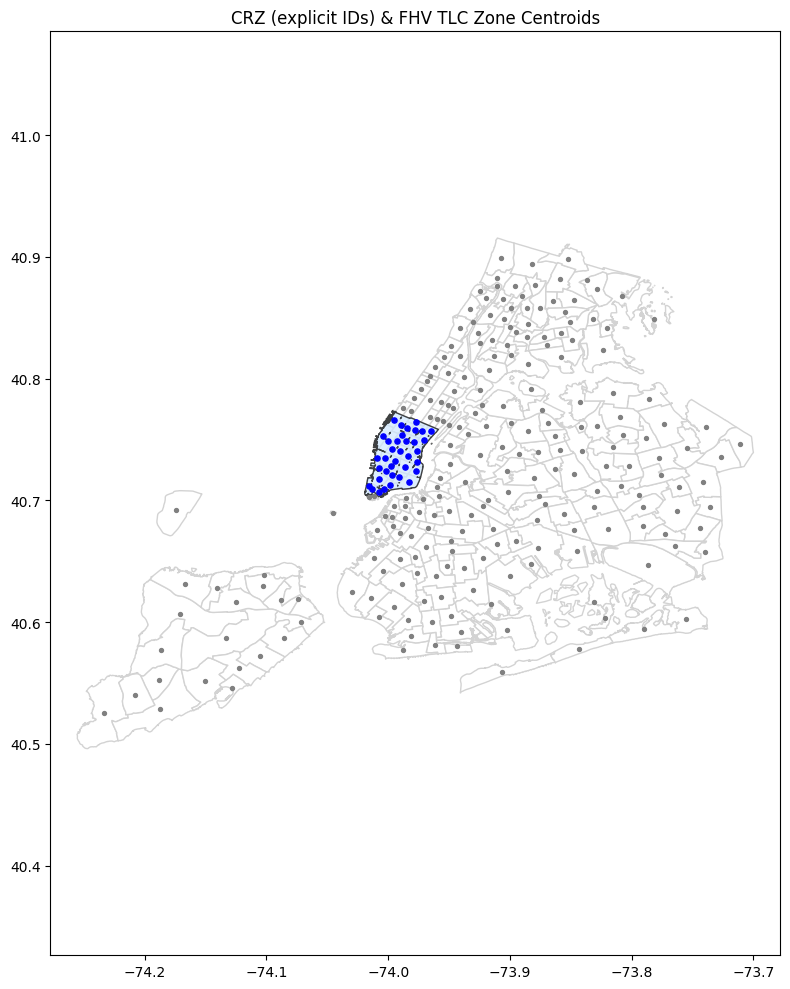

In [ ]:
import io, zipfile, tempfile, requests
import pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
FHV_URL      = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhv_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
START_HOUR, END_HOUR = 5, 10  # 5–10 AM (pickup time)

# CRZ defined by explicit TLC zone IDs (237 intentionally EXCLUDED)
CBD_ZONE_IDS = {
    4, 13, 45, 48, 50, 68, 79, 87, 90, 100, 107, 113, 114, 125, 137, 144, 148,
    158, 161, 162, 163, 164, 170, 186, 209, 211, 224, 229, 230, 231, 232, 233,
    234, 246, 249, 261
}

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

def build_cbd(zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """CRZ polygon = union of explicit zone geometries."""
    sub = zones[zones["locationid"].isin(CBD_ZONE_IDS)]
    if sub.empty:
        raise ValueError("No zones matched CBD_ZONE_IDS; check the list.")
    crz_geom = unary_union(sub.geometry.values).buffer(0)
    return gpd.GeoDataFrame({"name": ["CRZ_manual_ids"]}, geometry=[crz_geom], crs="EPSG:4326")

def in_cbd_series(zones: gpd.GeoDataFrame, cbd_gdf: gpd.GeoDataFrame) -> pd.Series:
    """Zone is in CRZ iff its LocationID is in the explicit list."""
    s = zones.set_index("locationid").index.to_series().isin(CBD_ZONE_IDS)
    s.index.name = "locationid"
    return s.astype(bool)

def plot_map(zones, inside):
    z = zones.copy(); z["in_cbd"] = z["locationid"].map(inside)
    crz = unary_union(z.loc[z["in_cbd"], "geometry"])
    crz_g = gpd.GeoDataFrame(geometry=[crz], crs=4326)

    fig, ax = plt.subplots(figsize=(8, 10))
    zones.plot(ax=ax, facecolor="white", edgecolor="lightgray")
    crz_g.plot(ax=ax, facecolor="#cfe8ff", edgecolor="black", alpha=0.7)
    c = z.geometry.centroid
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==False], crs=4326).plot(ax=ax, color="gray", markersize=8)
    gpd.GeoDataFrame(geometry=c[z["in_cbd"]==True],  crs=4326).plot(ax=ax, color="blue", markersize=14)
    ax.set_aspect("equal", "datalim"); ax.set_title("CRZ (explicit IDs) & FHV TLC Zone Centroids")
    plt.tight_layout(); plt.savefig("fhv_crz_map.png", dpi=200)
    print("Saved map to fhv_crz_map.png")

# ----------------------------
# MAIN
# ----------------------------
print("Loading zones & CRZ definition…")
zones  = load_zones(ZONES_ZIP_URL)
cbd    = build_cbd(zones)
inside = in_cbd_series(zones, cbd)

print("Loading FHV data…")
# FHV uses PUlocationID / DOlocationID / pickup_datetime
df = pd.read_parquet(FHV_URL, columns=["PUlocationID","DOlocationID","pickup_datetime"])
df = df.dropna(subset=["PUlocationID","DOlocationID","pickup_datetime"])
df["PULocationID"] = pd.to_numeric(df["PUlocationID"], errors="coerce").astype("Int64")
df["DOLocationID"] = pd.to_numeric(df["DOlocationID"], errors="coerce").astype("Int64")
df["pickup_dt"]    = pd.to_datetime(df["pickup_datetime"], errors="coerce")
df = df.dropna(subset=["pickup_dt","PULocationID","DOLocationID"]).copy()

# Merge CRZ flags (by explicit IDs)
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: Weekdays Aug 2025, pickup 5–10 AM
dt = df["pickup_dt"]
mask = (
    (dt.dt.year == 2025) & (dt.dt.month == 8) &
    (dt.dt.weekday < 5) &
    (dt.dt.hour >= START_HOUR) & (dt.dt.hour < END_HOUR)
)
df = df[mask].copy()

# Directional counts (no fee in standard FHV)
within            = df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"])].copy()
outside_inside    = df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"])].copy()
inside_outside    = df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"])].copy()
outside_outside   = df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"])].copy()

# Average per weekday in the window
num_days = df["pickup_dt"].dt.date.nunique()
daily = (lambda x: x / num_days) if num_days else (lambda x: float("nan"))

print("\n=== FHV — Directional Trip Counts (Weekdays Aug 2025, Pickup 5–10 AM) ===")
print(f"Inside → Inside   : {len(within):>10,}  (≈ {daily(len(within)):,.1f}/day)")
print(f"Outside → Inside  : {len(outside_inside):>10,}  (≈ {daily(len(outside_inside)):,.1f}/day)")
print(f"Inside → Outside  : {len(inside_outside):>10,}  (≈ {daily(len(inside_outside)):,.1f}/day)")
print(f"Outside → Outside : {len(outside_outside):>10,}  (≈ {daily(len(outside_outside)):,.1f}/day)")

total = len(within) + len(outside_inside) + len(inside_outside) + len(outside_outside)
print(f"\nTotal trips (all flows): {total:,}")

plot_map(zones, inside)


In [ ]:
mask = df['PU_in_cbd'] | df['DO_in_cbd']
df_cbd_4 = df[mask]

# 2. Group by day and count trips
df_cbd_4['pickup_dt'] = df_cbd_4['pickup_datetime'].dt.date
daily_flow_4 = df_cbd_4.groupby('pickup_dt').size()

# 3. Maximum total flow across all days
max_flow = daily_flow_4.max()

# (optional) The day(s) with that maximum flow
max_days = daily_flow_4[daily_flow_4 == max_flow]

print("Maximum total CBD-related flow on a single day:", max_flow)
print("Day(s) achieving this:")
print(max_days)

Maximum total CBD-related flow on a single day: 801
Day(s) achieving this:
pickup_dt
2025-08-04    801
dtype: int64


/tmp/ipython-input-980732939.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cbd_4['pickup_dt'] = df_cbd_4['pickup_datetime'].dt.date


In [ ]:
total_flow = daily_flow_1 + daily_flow_2 + daily_flow_3 + daily_flow_4
max_value = total_flow.max()
max_day = total_flow.idxmax()

print("Maximum total flow:", max_value)
print("Day with maximum flow:", max_day)

Maximum total flow: 54609
Day with maximum flow: 2025-08-06


In [ ]:
import io, zipfile, tempfile, requests, pandas as pd, geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
YELLOW_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM (drop-off time)

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load Yellow Taxi data (use DROP-OFF time)
cols = ["PULocationID","DOLocationID","tpep_dropoff_datetime","cbd_congestion_fee"]
df = pd.read_parquet(YELLOW_URL, columns=cols)
df = df.dropna(subset=["PULocationID","DOLocationID","tpep_dropoff_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["dropoff_dt"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")
df = df.dropna(subset=["dropoff_dt"])
df["cbd_congestion_fee"] = df["cbd_congestion_fee"].fillna(0)

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: WEEKDAYS in Aug 2025, DROP-OFF time 5–10 AM
dt = df["dropoff_dt"]
mask = (
    (dt.dt.year==2025) & (dt.dt.month==8) &
    (dt.dt.weekday<5) & (dt.dt.hour>=START_HOUR) & (dt.dt.hour<END_HOUR)
)
df = df[mask].copy()

# Identify fee-paying trips
df["pays_fee"] = df["cbd_congestion_fee"] > 0

# --- Fee-paying directional categories (by CRZ PU/DO) ---
inside_inside_paid   = len(df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
outside_inside_paid  = len(df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
inside_outside_paid  = len(df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])
outside_outside_paid = len(df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])

# Daily averages (by drop-off date)
num_days = df["dropoff_dt"].dt.date.nunique()
daily = lambda x: (x / num_days) if num_days else float("nan")

print("\n=== Yellow Taxi — Fee-paying Flow Matrix (Drop-off 5–10 AM, Weekdays Aug 2025) ===")
print(f"Inside → Inside   : {inside_inside_paid:>10,}  (≈ {daily(inside_inside_paid):,.1f}/day)")
print(f"Outside → Inside  : {outside_inside_paid:>10,}  (≈ {daily(outside_inside_paid):,.1f}/day)")
print(f"Inside → Outside  : {inside_outside_paid:>10,}  (≈ {daily(inside_outside_paid):,.1f}/day)")
print(f"Outside → Outside : {outside_outside_paid:>10,}  (≈ {daily(outside_outside_paid):,.1f}/day)")

total_paid = inside_inside_paid + outside_inside_paid + inside_outside_paid + outside_outside_paid
pct = lambda x: (100 * x / total_paid) if total_paid else float("nan")

print(f"\nTotal fee-paying trips (all flows): {total_paid:,}")
print("\nShare of fee-paying trips by flow (%):")
print(f"Inside→Inside   : {pct(inside_inside_paid):.1f}%")
print(f"Outside→Inside  : {pct(outside_inside_paid):.1f}%")
print(f"Inside→Outside  : {pct(inside_outside_paid):.1f}%")
print(f"Outside→Outside : {pct(outside_outside_paid):.1f}%")


/tmp/ipython-input-519155452.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-519155452.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-519155452.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)



=== Yellow Taxi — Fee-paying Flow Matrix (Drop-off 5–10 AM, Weekdays Aug 2025) ===
Inside → Inside   :    112,088  (≈ 5,337.5/day)
Outside → Inside  :     68,408  (≈ 3,257.5/day)
Inside → Outside  :     34,906  (≈ 1,662.2/day)
Outside → Outside :      8,419  (≈ 400.9/day)

Total fee-paying trips (all flows): 223,821

Share of fee-paying trips by flow (%):
Inside→Inside   : 50.1%
Outside→Inside  : 30.6%
Inside→Outside  : 15.6%
Outside→Outside : 3.8%


In [ ]:
import io, zipfile, tempfile, requests, pandas as pd, geopandas as gpd
from shapely.geometry import box
from shapely.ops import unary_union

# ----------------------------
# CONFIG
# ----------------------------
HVFHV_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2025-08.parquet"
ZONES_ZIP_URL = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"

LAT_60TH_ST = 40.7650
OVERRIDE_INCLUDE = {50}
OVERRIDE_EXCLUDE = {105, 202, 104, 103}
START_HOUR, END_HOUR = 5, 10  # 5–10 AM (drop-off time)

# ----------------------------
# HELPERS
# ----------------------------
def load_zones(url):
    r = requests.get(url, timeout=120); r.raise_for_status()
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(io.BytesIO(r.content)) as zf: zf.extractall(td)
        gdf = gpd.read_file(td)
    gdf = gdf.to_crs(4326)
    gdf = gdf.rename(columns={c: c.lower() for c in gdf.columns})
    gdf["locationid"] = gdf["locationid"].astype(int)
    gdf = gdf.drop_duplicates("locationid")
    return gdf[["locationid","borough","zone","geometry"]]

def build_cbd(zones):
    man = zones[zones["borough"].str.lower()=="manhattan"]
    poly = unary_union(man.geometry)
    south = box(-180,-90,180,LAT_60TH_ST)
    cbd = poly.intersection(south)
    return gpd.GeoDataFrame({"name":["CRZ"]}, geometry=[cbd], crs=4326)

def in_cbd_series(zones,cbd):
    poly=cbd.geometry.iloc[0]
    z=zones.copy(); z["centroid"]=z.geometry.centroid
    z["in_cbd"]=z["centroid"].apply(lambda p:p.within(poly) or p.touches(poly))
    s=z.groupby("locationid")["in_cbd"].any(); s.index=s.index.astype(int)
    for i in OVERRIDE_INCLUDE: s.loc[i]=True
    for i in OVERRIDE_EXCLUDE: s.loc[i]=False
    return s

# ----------------------------
# MAIN
# ----------------------------
zones = load_zones(ZONES_ZIP_URL)
cbd = build_cbd(zones)
inside = in_cbd_series(zones,cbd)

# Load HVFHV data (use DROP-OFF time; fee available)
cols = ["PULocationID","DOLocationID","dropoff_datetime","cbd_congestion_fee"]
df = pd.read_parquet(HVFHV_URL, columns=cols)
df = df.dropna(subset=["PULocationID","DOLocationID","dropoff_datetime"])
df["PULocationID"] = df["PULocationID"].astype("int32")
df["DOLocationID"] = df["DOLocationID"].astype("int32")
df["dropoff_dt"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
df = df.dropna(subset=["dropoff_dt"])
df["cbd_congestion_fee"] = df["cbd_congestion_fee"].fillna(0)

# Merge CRZ flags
df = df.merge(inside.rename("PU_in_cbd"), left_on="PULocationID", right_index=True, how="left")
df = df.merge(inside.rename("DO_in_cbd"), left_on="DOLocationID", right_index=True, how="left")
df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool)

# Filter: WEEKDAYS in Aug 2025, DROP-OFF time 5–10 AM
dt = df["dropoff_dt"]
mask = (
    (dt.dt.year==2025) & (dt.dt.month==8) &
    (dt.dt.weekday<5) & (dt.dt.hour>=START_HOUR) & (dt.dt.hour<END_HOUR)
)
df = df[mask].copy()

# Fee-paying trips
df["pays_fee"] = df["cbd_congestion_fee"] > 0

# Directional fee-paying counts
inside_inside_paid   = len(df[( df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
outside_inside_paid  = len(df[(~df["PU_in_cbd"]) & ( df["DO_in_cbd"]) & (df["pays_fee"])])
inside_outside_paid  = len(df[( df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])
outside_outside_paid = len(df[(~df["PU_in_cbd"]) & (~df["DO_in_cbd"]) & (df["pays_fee"])])

# Daily averages (by drop-off date)
num_days = df["dropoff_dt"].dt.date.nunique()
daily = lambda x: (x / num_days) if num_days else float("nan")

print("\n=== HVFHV — Fee-paying Flow Matrix (Drop-off 5–10 AM, Weekdays Aug 2025) ===")
print(f"Inside → Inside   : {inside_inside_paid:>10,}  (≈ {daily(inside_inside_paid):,.1f}/day)")
print(f"Outside → Inside  : {outside_inside_paid:>10,}  (≈ {daily(outside_inside_paid):,.1f}/day)")
print(f"Inside → Outside  : {inside_outside_paid:>10,}  (≈ {daily(inside_outside_paid):,.1f}/day)")
print(f"Outside → Outside : {outside_outside_paid:>10,}  (≈ {daily(outside_outside_paid):,.1f}/day)")

total_paid = inside_inside_paid + outside_inside_paid + inside_outside_paid + outside_outside_paid
pct = lambda x: (100 * x / total_paid) if total_paid else float("nan")

print(f"\nTotal fee-paying trips (all flows): {total_paid:,}")
print("\nShare of fee-paying trips by flow (%):")
print(f"Inside→Inside   : {pct(inside_inside_paid):.1f}%")
print(f"Outside→Inside  : {pct(outside_inside_paid):.1f}%")
print(f"Inside→Outside  : {pct(inside_outside_paid):.1f}%")
print(f"Outside→Outside : {pct(outside_outside_paid):.1f}%")


/tmp/ipython-input-2439794979.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  z=zones.copy(); z["centroid"]=z.geometry.centroid
/tmp/ipython-input-2439794979.py:66: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["PU_in_cbd"] = df["PU_in_cbd"].fillna(False).astype(bool)
/tmp/ipython-input-2439794979.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["DO_in_cbd"] = df["DO_in_cbd"].fillna(False).astype(bool


=== HVFHV — Fee-paying Flow Matrix (Drop-off 5–10 AM, Weekdays Aug 2025) ===
Inside → Inside   :    263,956  (≈ 12,569.3/day)
Outside → Inside  :    238,039  (≈ 11,335.2/day)
Inside → Outside  :    172,158  (≈ 8,198.0/day)
Outside → Outside :     48,119  (≈ 2,291.4/day)

Total fee-paying trips (all flows): 722,272

Share of fee-paying trips by flow (%):
Inside→Inside   : 36.5%
Outside→Inside  : 33.0%
Inside→Outside  : 23.8%
Outside→Outside : 6.7%
